# Colaba AQI — Exploratory Data Analysis

**Station:** Colaba, Mumbai  
**Period:** Jan 2021 – Dec 2025  
**Granularity (raw):** Hourly → resampled to Daily  
**Target variable:** `AQI` (Daily Mean)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Preprocess Data

In [14]:
STATION_NAME = 'Colaba'
# Load data
df = pd.read_csv(f'D:/AQI_Project_new/Data/Final/{STATION_NAME}_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# Interpolate missing AQI values (only 7 missing)
df['AQI'] = df['AQI'].interpolate(method='time')

# Resample to daily mean
daily = df['AQI'].resample('D').mean().dropna()

print(f'Total daily records: {len(daily)}')
print(f'Date range: {daily.index[0].date()} to {daily.index[-1].date()}')
print(f'AQI stats:\n{daily.describe()}')

Total daily records: 1826
Date range: 2021-01-01 to 2025-12-31
AQI stats:
count    1826.000000
mean       94.040515
std        59.015638
min        17.086667
25%        49.044583
50%        80.098958
75%       118.615938
max       386.450417
Name: AQI, dtype: float64


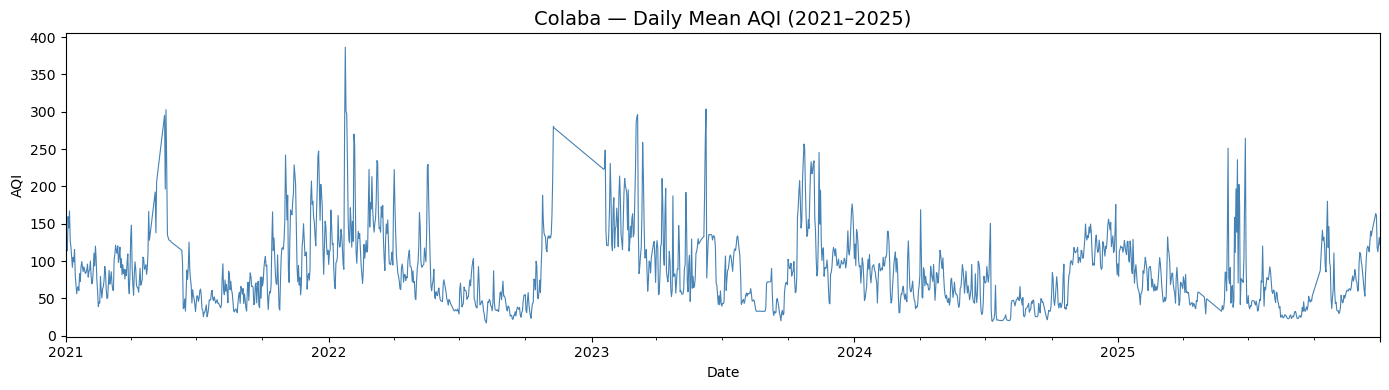

In [15]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.set_title(f'{STATION_NAME} — Daily Mean AQI (2021-2025)', fontsize=14)
ax.set_ylabel('AQI')
ax.set_xlabel('Date')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/arima_full_series_{STATION_NAME}.png', dpi=150)
plt.show()

## 2. Stationarity Check (ADF Test)

In [16]:
result = adfuller(daily.dropna())
print('ADF Test on original series:')
print(f'  ADF Statistic : {result[0]:.4f}')
print(f'  p-value       : {result[1]:.4f}')
print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
print()
if result[1] < 0.05:
    print('Series is STATIONARY (d=0 may suffice).')
else:
    print('Series is NON-STATIONARY → differencing needed (d=1).')

# Check first difference
result_d1 = adfuller(daily.diff().dropna())
print(f'\nADF on first difference: p-value = {result_d1[1]:.4f}')
if result_d1[1] < 0.05:
    print('First difference is stationary → d=1 confirmed.')

ADF Test on original series:
  ADF Statistic : -4.4498
  p-value       : 0.0002
  Critical 1%   : -3.4340
  Critical 5%   : -2.8631

Series is STATIONARY (d=0 may suffice).

ADF on first difference: p-value = 0.0000
First difference is stationary → d=1 confirmed.


## 3. ACF & PACF Plots

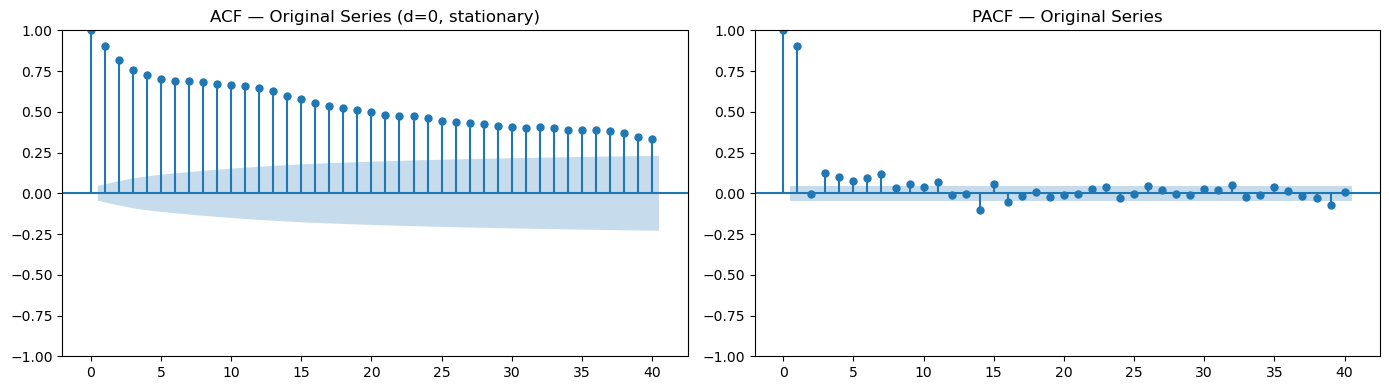

ACF/PACF suggests: p=2, d=0, q=2


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily, lags=40, ax=axes[0], title='ACF — Original Series (d=0, stationary)')
plot_pacf(daily, lags=40, ax=axes[1], title='PACF — Original Series')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/arima_acf_pacf_{STATION_NAME}.png', dpi=150)
plt.show()
print('ACF/PACF suggests: p=2, d=0, q=2')


## 4. Train/Test Split

In [18]:
# Use last ~10% as test (~184 days)
split_date = '2025-07-01'
train = daily[:split_date]
test  = daily[split_date:]

print(f'Train: {len(train)} days ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} days ({test.index[0].date()} → {test.index[-1].date()})')


Train: 1643 days (2021-01-01 → 2025-07-01)
Test : 184 days (2025-07-01 → 2025-12-31)


## 5. Fit Auto-ARIMA

In [19]:
import pmdarima as pm
print('Running Auto-ARIMA to find optimal parameters...')
auto_model = pm.auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, trace=True)
print(f'Optimal ARIMA order: {auto_model.order}')

model = ARIMA(train, order=auto_model.order)
fit   = model.fit()
print(fit.summary())

Running Auto-ARIMA to find optimal parameters...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=15311.099, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15468.823, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15467.870, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=15466.265, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15466.824, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=15313.800, Time=0.38 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=15311.723, Time=0.40 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=15315.719, Time=1.00 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=15309.745, Time=1.56 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=15314.311, Time=0.64 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=15306.952, Time=1.46 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=15311.604, Time=2.32 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=15308.559, Time=2.70 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   :

## 6. Forecast & Evaluation

In [20]:
forecast = fit.forecast(steps=len(test))
forecast.index = test.index

rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mask = test.values != 0
mape = np.mean(np.abs((test.values[mask] - forecast.values[mask]) / test.values[mask])) * 100

print(f'Auto-ARIMA Performance on Test Set:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


Auto-ARIMA Performance on Test Set:
  RMSE : 42.06
  MAE  : 37.37
  MAPE : 87.35%


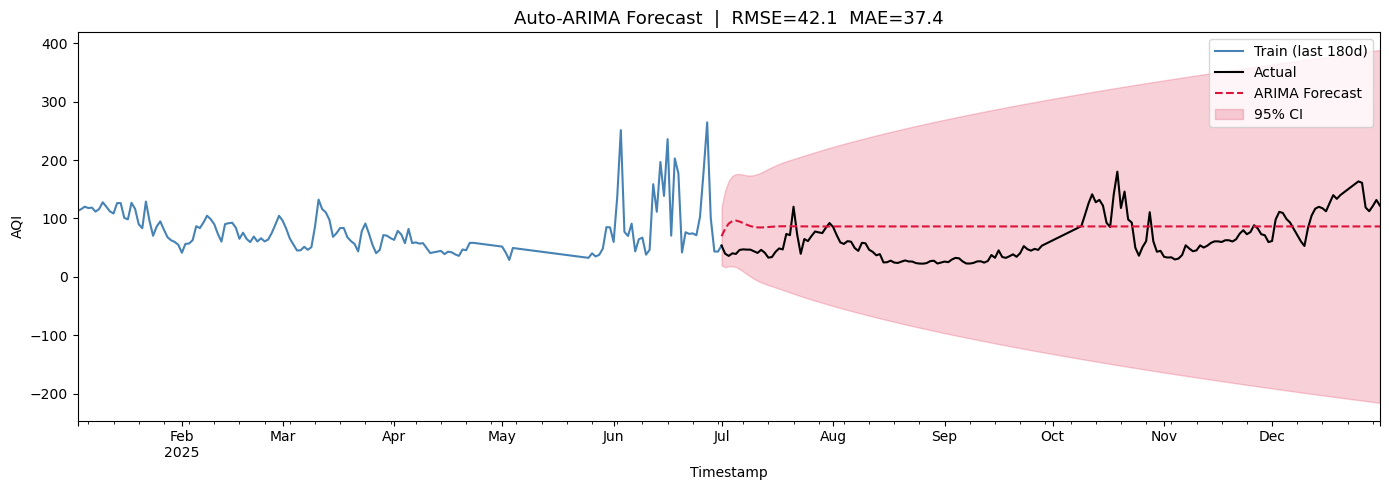

In [21]:
# Confidence interval forecast
pred_ci = fit.get_forecast(steps=len(test))
ci = pred_ci.conf_int()
ci.index = test.index

fig, ax = plt.subplots(figsize=(14, 5))
train[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
test.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
forecast.plot(ax=ax, label='ARIMA Forecast', color='crimson', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='crimson', label='95% CI')
ax.set_title(f'Auto-ARIMA Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/arima_forecast_{STATION_NAME}.png', dpi=150)
plt.show()

## 7. Residual Diagnostics

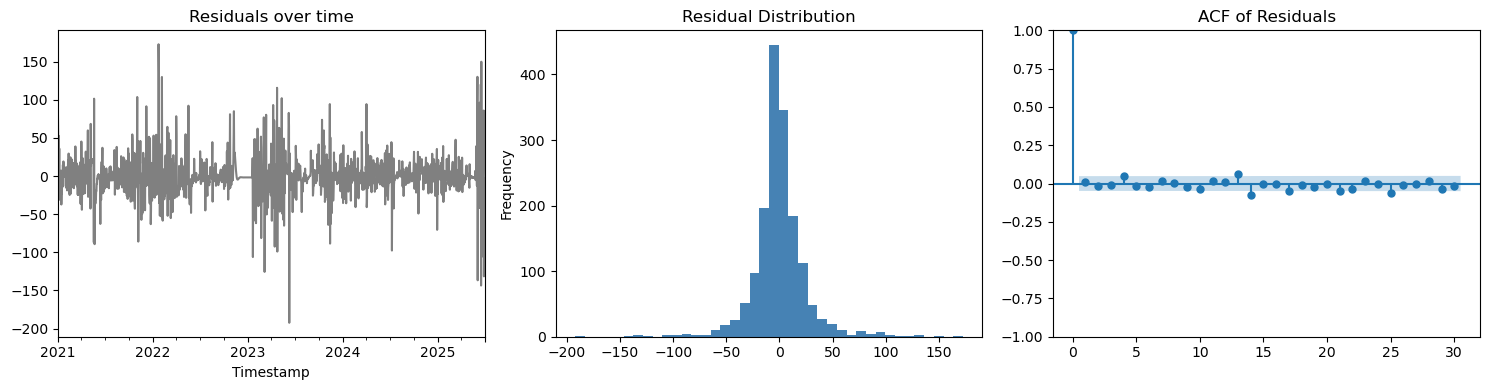

In [22]:
residuals = fit.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
residuals.plot(ax=axes[0], title='Residuals over time', color='gray')
residuals.plot(kind='hist', ax=axes[1], bins=40, title='Residual Distribution', color='steelblue')
plot_acf(residuals, lags=30, ax=axes[2], title='ACF of Residuals')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/arima_residuals_{STATION_NAME}.png', dpi=150)
plt.show()

## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate classification performance (Accuracy, Precision, Recall).

Classification Metrics for AQI Categories:
Accuracy:  0.3804
Precision: 0.1447 (Weighted)
Recall:    0.3804 (Weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        80
Satisfactory       0.38      1.00      0.55        70
    Moderate       0.00      0.00      0.00        34

    accuracy                           0.38       184
   macro avg       0.13      0.33      0.18       184
weighted avg       0.14      0.38      0.21       184



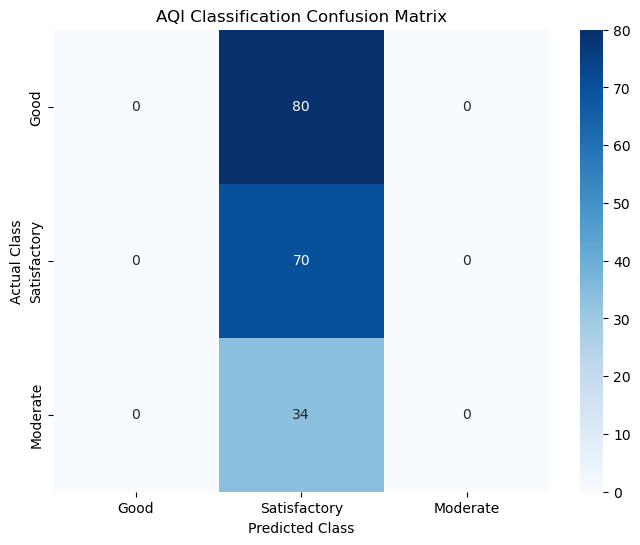

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Define AQI categories based on Indian standards
def categorize_aqi(aqi_values):
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)

# Ensure values are flattened arrays
y_true_cont = np.array(test.values).flatten()
y_pred_cont = np.array(forecast.values).flatten()

# Convert continuous predictions to discrete AQI classes
y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

# Labels for standard Indian AQI
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
# Filter labels to only those present in the actual or predicted to avoid empty rows/cols if desired
# But keeping all labels shows a full matrix
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

# Calculate Metrics
acc = accuracy_score(y_true_class, y_pred_class)
# weighted average for precision and recall since it's multiclass
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print(f"Classification Metrics for AQI Categories:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)\n")

print("Classification Report:")
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title('AQI Classification Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

os.makedirs('images', exist_ok=True)
plt.savefig('images/arima_confusion_matrix_colaba.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import pickle, os
os.makedirs('D:/AQI_Project_new/ARIMA/saved_models', exist_ok=True)
with open('D:/AQI_Project_new/ARIMA/saved_models/arima_colaba.pkl', 'wb') as f:
    pickle.dump(fit, f)
print('Model saved as arima_colaba.pkl')


Model saved as arima_colaba.pkl
